In [2]:
import pandas as pd;
import numpy as np;
id = [101, 102, 103,104,105];
name = ["Aman", "Simran", "Rahul", "Priya", "Karan"]
marks = [85,93,78,88,95]

df = pd.DataFrame({"ID": id,"name": name,"marks": marks})
df

print(np.mean(marks))
print(max(marks))
print(min(marks))
highest_marks = df[df["marks"] == df["marks"].max()]
print("heighest : \n",highest_marks)
lowest_marks = df[df["marks"] == df["marks"].min()]
print(lowest_marks)
print(df.loc[df["marks"].idxmax()])
print(df[df["marks"]>90])


df["Grade"] = df["marks"].apply(
    lambda x: "A+" if x > 90
    else "A" if x>=80
    else "B+" if x >= 70
    else "C"
)
df
print(df.sort_values(by="marks", ascending=False))



87.8
95
78
heighest : 
     ID   name  marks
4  105  Karan     95
    ID   name  marks
2  103  Rahul     78
ID         105
name     Karan
marks       95
Name: 4, dtype: object
    ID    name  marks
1  102  Simran     93
4  105   Karan     95
    ID    name  marks Grade
4  105   Karan     95    A+
1  102  Simran     93    A+
3  104   Priya     88     A
0  101    Aman     85     A
2  103   Rahul     78    B+


**Absent class data**

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\tarun\OneDrive\Desktop\INT324\employee.csv")
print(df.head(10))

print(df[df['Department'] == 'IT'])
print("Average Salary:",df['Salary'].mean())

print(df.loc[df['Salary'].idxmax()])

print(df.sort_values('Salary', ascending=False))


print(df.groupby('Department') ['Salary'].mean())

print(df.groupby('Department') ['Empid'].count())

df['Annual_salary'] = df['Salary']*12

print(df.head(8))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\tarun\\OneDrive\\Desktop\\INT324\\employee.csv'

# Absent in 2 classes


  customer_id   age  gender    country signup_date last_purchase_date  \
0       10001  56.0    Male      India  27-01-2022         27-04-2024   
1       10002  69.0   Other         UK  12-01-2025         01-08-2025   
2       10003  46.0  Female        USA  25-04-2021         01-06-2021   
3       10004  32.0    Male      India  23-02-2021         22-09-2023   
4       10005  60.0  Female      India  07-06-2021         11-12-2021   
5         ABC  25.0  Female        NaN  04-12-2021         18-11-2024   
6       10007  38.0  Female      India  04-01-2024         23-01-2024   
7       10008  56.0    Male  Australia  29-06-2022         28-03-2023   
8       10009  36.0    Male      India  20-11-2020         06-01-2024   
9       10010  40.0  Female      India  30-06-2024         08-09-2024   

   num_orders  total_spent  avg_order_value  recency_days  is_premium_member  \
0          10     13273.25          1327.32           522                  0   
1          10          NaN          

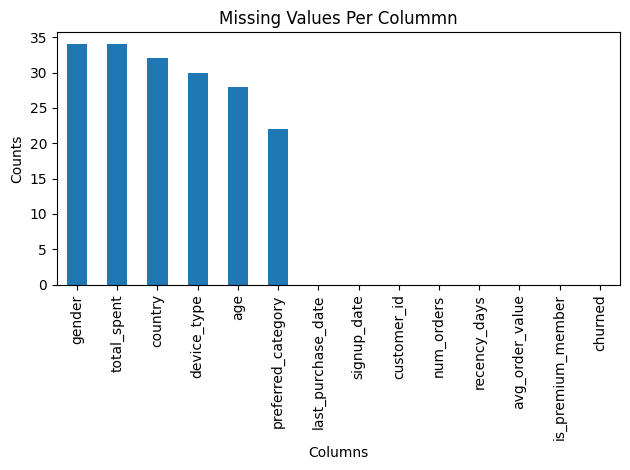

In [ ]:
# Friday class

import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\Downloads Alternative\ecommerce_customers_unit1.csv")
print(df.head(10))
print(df.info())
print("Shape Of the data:",df.shape)
print(df.describe())

print(df.isnull().sum())

missing_counts = df.isna().sum().sort_values(ascending = False)


missing_counts.plot(kind = "bar")
plt.title("Missing Values Per Colummn")
plt.xlabel("Columns")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()




In [ ]:

q1 = df['total_spent'].quantile(0.25)
q3 = df['total_spent'].quantile(0.75)
iqr = q3 - q1
print(iqr)


lb = q1-1.5*iqr
ub = q3+1.5*iqr
print(lb)
print(ub)

outlier = ((df['total_spent']<(lb)) | (df['total_spent'] > (ub))).sum()
print("Outliers found in column:", outlier,"\n")

5602.37
-4482.915
17926.565000000002
Outliers found in column: 21 



outliers found in each column: age                   0
num_orders            5
total_spent          23
avg_order_value      15
recency_days         10
is_premium_member     0
churned              22
dtype: int64 



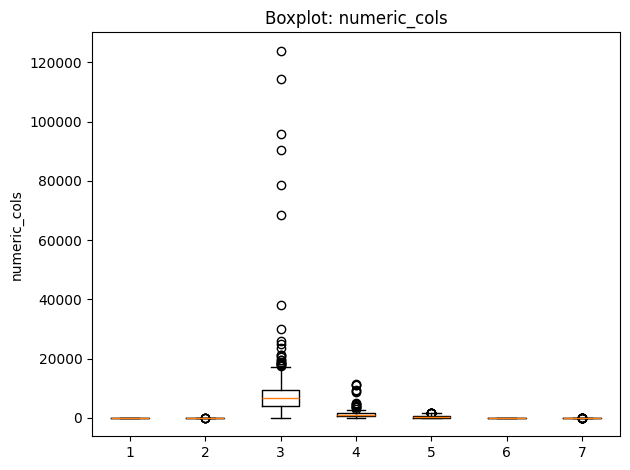

In [ ]:
numeric = df.select_dtypes(include = "number").columns
df[numeric] = df[numeric].fillna(df[numeric].mean())


q1= df[numeric].quantile(0.25)
q3= df[numeric].quantile(0.75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5*iqr

outliers = ((df[numeric] < (lower)) | (df[numeric] > (upper))).sum()
print("outliers found in each column:",outliers, "\n")

plt.boxplot(df[numeric])
plt.title("Boxplot: numeric_cols")
plt.ylabel("numeric_cols")
plt.tight_layout()
plt.show()



In [ ]:
# Remove rows containing outliers

data_clean = df[~((df[numeric] < lower) | (df[numeric] > upper)).any(axis =1)]

print("Original shape: ", df.shape)
print("After removing outliers", data_clean.shape)

Original shape:  (605, 14)
After removing outliers (547, 14)


In [ ]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['Color_encoded'] = le.fit_transform(df['Color'])
# print(df.columns.tolist())
# print(df.dtypes)
# print(df.head(10))

# Clean all column names first
df.columns = df.columns.str.strip().str.lower()

# Now use lowercase
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['color_encoded'] = le.fit_transform(df['color'])
print(df.head(10))






KeyError: 'color'

# Exploratory Data Analysis (EDA)

## Steps

1. **Understand the problem & data**
2. **Import and inspect the data**
3. **Handle missing data**
4. **Explore data characteristics**
5. **Perform data transformation**
6. **Detect and handle outliers**
7. **Analyse relationships and correlations**
8. **Visualize the data**
9. **Draw conclusions / Summarize findings**


In [28]:
# EDA

df = pd.read_csv("Data.csv")
print(df.isnull().sum())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df.info()
df.describe()
df.shape
# df

Name         0
Age          1
Gender       0
Country      0
Salary       1
Purchased    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       6 non-null      str    
 1   Age        5 non-null      float64
 2   Gender     6 non-null      str    
 3   Country    6 non-null      str    
 4   Salary     6 non-null      float64
 5   Purchased  6 non-null      str    
dtypes: float64(2), str(4)
memory usage: 420.0 bytes


(6, 6)